[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter13_seminar_notebook.ipynb)

# Statistics of Financial Markets — Seminar 13: Machine learning

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- This seminar comes before Lecture 13: the slides "What You Need for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with inference and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_13'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# the arch package (maximum-likelihood estimation of GARCH models) is not part of Google Colab
!pip install -q arch

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Data: returns, the daily variance proxy, the volatility features and target.
- Walk-forward forecasts, out-of-sample $R^2$, QLIKE and the Diebold–Mariano test; classifiers against the majority-class baseline; quantile regression VaR and its backtest.
- Helpers for Part A and Part B: bias and variance, a tree split, ridge and lasso with one feature, the walk-forward design, the purged K-fold counts, the solved exercises B1, B3 and B5.

In [ ]:
from matplotlib.patches import Rectangle, Circle
from sklearn.cluster import KMeans
from sklearn.ensemble import (GradientBoostingClassifier, GradientBoostingRegressor, RandomForestClassifier,
                              RandomForestRegressor)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (Lasso, LassoCV, LinearRegression, LogisticRegression, QuantileRegressor, Ridge,
                                  lasso_path)
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from arch import arch_model
TABLE_DIR = '.'
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'gbpusd': 'GBP/USD', 'usdjpy': 'USD/JPY'}
START = {'sp500': '2000-01-01', 'dax': '2000-01-01', 'bet': '2000-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01'}
OHLC_START = {'sp500': '2008-01-01', 'dax': '2006-01-01', 'btc': None}
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'tlv': '#E67E22', 'snp': '#2E7D32'}
MCOL = {'HAR': '#1A3A6E', 'Lasso': '#17A2B8', 'RF': '#2E7D32', 'GB': '#E67E22', 'MLP': '#8E44AD', 'Mean': '#B5853F', 'Logit': '#1A3A6E', 'QR': '#2E7D32', 'QGB': '#E67E22', 'HS': '#B5853F', 'GARCH-t': '#CD0000'}
H = 5
OOS = {'sp500': '2013-01-01', 'dax': '2012-01-01', 'btc': '2018-01-01', 'bet': '2008-01-01', 'tlv': '2014-01-01', 'snp': '2014-01-01'}
OOS_SIGN = {'sp500': '2008-01-01', 'dax': '2008-01-01', 'bet': '2008-01-01', 'btc': '2018-01-01', 'tlv': '2014-01-01', 'snp': '2014-01-01'}
HAR = ['d', 'w', 'm']
EXT = ['d', 'w', 'm', 'd1', 'd2', 'd3', 'd4', 'q', 'r', 'r_neg', 'abs_r']
FEAT_LABEL = {'d': 'log RV day', 'w': 'log RV week', 'm': 'log RV month', 'd1': 'log RV lag 1', 'd2': 'log RV lag 2', 'd3': 'log RV lag 3', 'd4': 'log RV lag 4', 'q': 'log RV quarter', 'r': 'return', 'r_neg': 'negative return', 'abs_r': 'absolute return'}
FEAT_COL = {'d': '#1A3A6E', 'w': '#CD0000', 'm': '#2E7D32', 'd1': '#17A2B8', 'd2': '#8E44AD', 'd3': '#E67E22', 'd4': '#B5853F', 'q': '#DC3545', 'r': '#6B8E23', 'r_neg': '#C71585', 'abs_r': '#00008B'}
SIGN_FEATS = ['r0', 'r1', 'r2', 'r3', 'r4', 'm5', 'm21', 'm63', 'v21', 'v63']
QV_FEATS = ['sd', 'sw', 'sm', 'r']
ALPHA_VAR = 0.01
HS_WINDOW = 500
SEED = 2026
N_TREES = 300
EULER = 0.5772156649
GKX_MODELS = ['OLS-3+H', 'PLS', 'PCR', 'ENet+H', 'GLM+H', 'RF', 'GBRT+H', 'NN1', 'NN2', 'NN3', 'NN4', 'NN5']
GKX_R2 = [0.16, 0.27, 0.26, 0.11, 0.19, 0.33, 0.34, 0.33, 0.39, 0.4, 0.39, 0.36]
GKX_R2_TOP = [0.31, -0.14, 0.06, 0.25, 0.14, 0.63, 0.52, 0.49, 0.62, 0.7, 0.67, 0.64]
GKX_SR = [0.61, 0.72, 0.88, 0.39, 0.76, 0.98, 0.81, 1.17, 1.16, 1.2, 1.35, 1.15]


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar; known data errors removed."""
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def fx_close(symbol, start='2000-01-01'):
    """Close of an exchange rate or yield from the course data: weekdays only, unchanged (holiday) closes dropped."""
    s = pd.to_numeric(read_market(symbol)['close'], errors='coerce').dropna().loc[start:END]
    s = s[s.index.dayofweek < 5]
    return s[s.diff() != 0]


def ohlc(k, start=None):
    """Open, high, low and close prices (indices and crypto as quoted). Weekend quotes and days without trading are
    dropped, except for crypto; inconsistent rows (high below open or close, low above them) are dropped."""
    symbol, _, group, field, start0 = SERIES[k]
    t = read_market(symbol).loc[(start or OHLC_START.get(k) or start0):END]
    t = t[['open', 'high', 'low', 'close']].apply(pd.to_numeric, errors='coerce').dropna()
    t = t[(t > 0).all(axis=1)]
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
        t = t[~((t['close'].diff() == 0) & (t['high'] == t['low']))]
    return t[(t['high'] >= t[['open', 'close']].max(axis=1)) & (t['low'] <= t[['open', 'close']].min(axis=1))]


def daily_variance(k):
    """Daily variance proxy of Chapter 8 (%^2): overnight return squared plus the Garman-Klass term,
    v_t = o_t^2 + 0.5 (u - d)^2 - (2 ln 2 - 1) c^2, with o = ln(O_t/C_t-1), u = ln(H/O), d = ln(L/O), c = ln(C/O)."""
    t = ohlc(k)
    lo, lh, ll, lc = (100 * np.log(t[c]) for c in ['open', 'high', 'low', 'close'])
    o, u, d, c = lo - lc.shift(), lh - lo, ll - lo, lc - lo
    v = (o ** 2 + 0.5 * (u - d) ** 2 - (2 * np.log(2) - 1) * c ** 2).dropna()
    r = (lc - lc.shift()).dropna()
    return v.clip(lower=0.01 * v.median()), r


def rv_frame(k, h=H):
    """Features at the close of day t and the target: y = log of the mean variance proxy over days t+1..t+h.
    HAR features: d = log v_t, w = log mean(v_t-4..v_t), m = log mean(v_t-21..v_t); extended: lags 1-4 of d,
    q = log mean over 66 days, the return r_t, its negative part and its absolute value."""
    v, r = daily_variance(k)
    X = pd.DataFrame({'d': np.log(v), 'w': np.log(v.rolling(5).mean()), 'm': np.log(v.rolling(22).mean()),
                      'q': np.log(v.rolling(66).mean())})
    for j in range(1, 5):
        X[f'd{j}'] = X['d'].shift(j)
    X['r'] = r
    X['r_neg'] = r.clip(upper=0)
    X['abs_r'] = r.abs()
    fut = sum(v.shift(-j) for j in range(1, h + 1)) / h
    X['rv'] = fut                       # target in levels (%^2 per day), for QLIKE
    X['y'] = np.log(fut)                # target in logs
    return X.dropna()


class MLPEnsemble:
    """The average of several small MLPs (different random starting weights); inputs and target standardised.
    One hidden layer with 16 ReLU neurons, L2 penalty alpha, Adam optimiser, a fixed number of epochs."""

    def __init__(self, hidden=(16,), alpha=1e-2, n_models=5, epochs=200, seed=SEED):
        self.hidden, self.alpha, self.n_models, self.epochs, self.seed = hidden, alpha, n_models, epochs, seed

    def fit(self, X, y):
        self.sx = StandardScaler().fit(X)
        self.my, self.sy = float(np.mean(y)), float(np.std(y))
        Z, t = self.sx.transform(X), (np.asarray(y) - self.my) / self.sy
        self.models = [MLPRegressor(hidden_layer_sizes=self.hidden, alpha=self.alpha, max_iter=self.epochs,
                                    random_state=self.seed + i).fit(Z, t) for i in range(self.n_models)]
        return self

    def predict(self, X):
        Z = self.sx.transform(X)
        return self.my + self.sy * np.mean([m.predict(Z) for m in self.models], axis=0)


def walk_forward(X, feats, make_model, oos_start, h=H, target='y'):
    """Yearly refits on an expanding window: for each test year, train on all earlier rows except the last h, whose
    targets overlap the test year (purging), then forecast every row of the year. Also returns the residual variance
    of the training fit (for the log-normal correction exp(yhat + s^2/2))."""
    test_years = sorted(set(X.index[X.index >= oos_start].year))
    pred, s2 = pd.Series(np.nan, index=X.index), pd.Series(np.nan, index=X.index)
    for yr in test_years:
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01']
        tr = tr.iloc[:-h] if h > 0 else tr
        m = make_model().fit(tr[feats], tr[target])
        pred[te] = m.predict(X.loc[te, feats])
        s2[te] = float(np.var(tr[target] - m.predict(tr[feats])))
    keep = X.index >= oos_start
    return pd.DataFrame({'pred': pred[keep], 's2': s2[keep]})


class MeanModel:
    """Benchmark: the mean of the training target."""

    def fit(self, X, y):
        self.m = float(np.mean(y))
        return self

    def predict(self, X):
        return np.full(len(X), self.m)


def rv_models(seed=SEED):
    """The five forecasting models of the realised variance (features, model factory)."""
    return {
        'Mean': (HAR, lambda: MeanModel()),
        'HAR': (HAR, lambda: LinearRegression()),
        'Lasso': (EXT, lambda: make_pipeline(StandardScaler(), LassoCV(cv=TimeSeriesSplit(5, gap=H), n_alphas=40))),
        'RF': (EXT, lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, max_features=0.5,
                                                  n_jobs=-1, random_state=seed)),
        'GB': (EXT, lambda: GradientBoostingRegressor(n_estimators=300, learning_rate=0.03, max_depth=3, subsample=0.8,
                                                      random_state=seed)),
        'MLP': (EXT, lambda: MLPEnsemble(seed=seed)),
    }


def qlike(rv, h):
    """QLIKE loss of Chapter 8: L = RV / h + ln h (lower is better)."""
    return rv / h + np.log(h)


def dm_test(d, lag=H):
    """Diebold-Mariano statistic for the mean of a loss difference d_t, with a Newey-West (Bartlett) long-run variance
    of `lag` lags; two-sided p-value from N(0, 1)."""
    d = np.asarray(d, float)
    n, u = len(d), d - d.mean()
    lrv = np.sum(u * u) / n
    for j in range(1, lag + 1):
        lrv += 2 * (1 - j / (lag + 1)) * np.sum(u[j:] * u[:-j]) / n
    t = d.mean() / np.sqrt(lrv / n)
    return float(t), float(2 * stats.norm.sf(abs(t)))


def oos_r2(y, yhat, ybar):
    """Out-of-sample R^2 against a benchmark forecast ybar: 1 - sum (y - yhat)^2 / sum (y - ybar)^2."""
    y, yhat, ybar = (np.asarray(a, float) for a in (y, yhat, ybar))
    return float(1 - np.sum((y - yhat) ** 2) / np.sum((y - ybar) ** 2))


def rv_forecasts(k, models=None, h=H):
    """Walk-forward forecasts of all models for one series, with the variance forecast exp(yhat + s^2/2)."""
    X = rv_frame(k, h)
    models = models or rv_models()
    P = {}
    for name, (feats, make) in models.items():
        f = walk_forward(X, feats, make, OOS[k], h)
        f['var'] = np.exp(f['pred'] + f['s2'] / 2)
        P[name] = f
    return X, P


def rv_metrics(X, P, bench='HAR', h=H):
    """Out-of-sample R^2 against the training mean and against HAR (log RV), QLIKE, and the Diebold-Mariano test of
    equal QLIKE against HAR."""
    idx = P[bench].index
    y, rv = X.loc[idx, 'y'], X.loc[idx, 'rv']
    out = {}
    for name, f in P.items():
        L = qlike(rv, f['var'])
        Lb = qlike(rv, P[bench]['var'])
        t, p = dm_test(L - Lb, h) if name != bench else (np.nan, np.nan)
        out[name] = {'mse': float(np.mean((y - f['pred']) ** 2)), 'r2_mean': oos_r2(y, f['pred'], P['Mean']['pred']),
                     'r2_har': oos_r2(y, f['pred'], P[bench]['pred']), 'qlike': float(L.mean()), 'dm_t': t, 'dm_p': p}
    out['n'] = int(len(idx))
    out['first'] = idx[0].date().isoformat()
    out['last'] = idx[-1].date().isoformat()
    return out


def wf_design(k='sp500', h=H):
    """The walk-forward design of the volatility forecasts: one fold per test year, an expanding training window, the
    last h training rows purged (their targets reach into the test year)."""
    X = rv_frame(k, h)
    years = sorted(set(X.index[X.index >= OOS[k]].year))
    rows = []
    for yr in years:
        tr = X[X.index < f'{yr}-01-01']
        rows.append({'year': int(yr), 'n_train': int(len(tr) - h), 'n_test': int((X.index.year == yr).sum()),
                     'last_train': tr.index[-h - 1].date().isoformat(), 'first_purged': tr.index[-h].date().isoformat()})
    return {'n_folds': len(years), 'first': X.index[0].date().isoformat(), 'rows': rows, 'h': h}


def sign_frame(k):
    """Features at the close of day t (the last five returns, sums over 5, 21 and 63 days, volatility over 21 and 63
    days) and the target 1{r_t+1 > 0}."""
    r = returns(k)
    X = pd.DataFrame({f'r{j}': r.shift(j) for j in range(5)})
    X['m5'], X['m21'], X['m63'] = r.rolling(5).sum(), r.rolling(21).sum(), r.rolling(63).sum()
    X['v21'], X['v63'] = r.rolling(21).std(), r.rolling(63).std()
    X['y'] = (r.shift(-1) > 0).astype(float)
    X['ret'] = r.shift(-1)
    return X.dropna()


def sign_models(seed=SEED):
    return {'Logit': lambda: make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000)),
            'RF': lambda: RandomForestClassifier(n_estimators=N_TREES, min_samples_leaf=100, max_features=0.5, n_jobs=-1,
                                                 random_state=seed),
            'GB': lambda: GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=2, subsample=0.8,
                                                     random_state=seed)}


def sign_walk_forward(k, models=None, oos_start=None):
    """Yearly walk-forward classification; the majority class of the training sample is the baseline forecast."""
    X = sign_frame(k)
    oos_start = oos_start or OOS_SIGN[k]
    models = models or sign_models()
    keep = X.index >= oos_start
    prob = {m: pd.Series(np.nan, index=X.index) for m in models}
    base = pd.Series(np.nan, index=X.index)
    for yr in sorted(set(X.index[keep].year)):
        te = X.index.year == yr
        tr = X[X.index < f'{yr}-01-01'].iloc[:-1]
        base[te] = float(tr['y'].mean() >= 0.5)
        for name, make in models.items():
            m = make().fit(tr[SIGN_FEATS], tr['y'].astype(int))
            prob[name][te] = m.predict_proba(X.loc[te, SIGN_FEATS])[:, 1]
    return X[keep], {m: p[keep] for m, p in prob.items()}, base[keep]


def sign_metrics(X, prob, base):
    """Accuracy of each model and of the baseline; z test of the accuracy against the baseline rate; AUC."""
    y = X['y'].values
    acc_b = float(np.mean(base.values == y))
    n = len(y)
    out = {'n': int(n), 'up': float(y.mean()), 'base_acc': acc_b, 'first': X.index[0].date().isoformat()}
    for name, p in prob.items():
        acc = float(np.mean((p.values >= 0.5) == y))
        z = (acc - acc_b) / np.sqrt(acc_b * (1 - acc_b) / n)
        out[name] = {'acc': acc, 'diff': acc - acc_b, 'z': float(z), 'p': float(2 * stats.norm.sf(abs(z))),
                     'auc': float(roc_auc_score(y, p.values)), 'share_up_pred': float(np.mean(p.values >= 0.5))}
    return out


def qvar_frame(k):
    """Features at the close of day t: the square roots of the variance proxy over 1, 5 and 22 days (daily volatility
    in %) and the return r_t; target: the next log return r_t+1 (%)."""
    v, r = daily_variance(k)
    X = pd.DataFrame({'sd': np.sqrt(v), 'sw': np.sqrt(v.rolling(5).mean()), 'sm': np.sqrt(v.rolling(22).mean()), 'r': r})
    X['y'] = r.shift(-1)
    return X.dropna()


def quantile_models(a=ALPHA_VAR, seed=SEED):
    return {'QR': lambda: QuantileRegressor(quantile=a, alpha=0.0, solver='highs'),
            'QGB': lambda: GradientBoostingRegressor(loss='quantile', alpha=a, n_estimators=300, learning_rate=0.05,
                                                     max_depth=2, min_samples_leaf=50, subsample=0.8, random_state=seed)}


def kupiec(x, n, a=ALPHA_VAR):
    """Kupiec POF test: LR_uc and its chi-square(1) p-value."""
    ph = x / n
    l0 = (n - x) * np.log(1 - a) + x * np.log(a)
    l1 = (n - x) * np.log(1 - ph) + (x * np.log(ph) if x > 0 else 0.0)
    lr = -2 * (l0 - l1)
    return float(lr), float(stats.chi2.sf(lr, 1))


def christoffersen(hits):
    """Christoffersen independence test: LR_ind and its chi-square(1) p-value, from the transition counts."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    n00, n01 = np.sum((a == 0) & (b == 0)), np.sum((a == 0) & (b == 1))
    n10, n11 = np.sum((a == 1) & (b == 0)), np.sum((a == 1) & (b == 1))
    p01, p11 = n01 / max(n00 + n01, 1), n11 / max(n10 + n11, 1)
    p = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    def ll(q, k0, k1):
        return (k0 * np.log(1 - q) if k0 else 0.0) + (k1 * np.log(q) if k1 else 0.0)
    lr = -2 * (ll(p, n00 + n10, n01 + n11) - ll(p01, n00, n01) - ll(p11, n10, n11))
    return float(lr), float(stats.chi2.sf(lr, 1)), int(n11)


def var_backtest(X, V, a=ALPHA_VAR):
    """Exceedances, Kupiec and Christoffersen p-values and the average quantile loss of each VaR forecast."""
    y = X['y']
    out = {'n': int(len(y)), 'first': X.index[0].date().isoformat()}
    for m in V:
        hit = (y < -V[m]).astype(int)
        x = int(hit.sum())
        lr, p = kupiec(x, len(y), a)
        lri, pi, n11 = christoffersen(hit)
        ql = float(np.mean((a - hit) * (y + V[m])))
        out[m] = {'x': x, 'rate': x / len(y), 'lr_uc': lr, 'p_uc': p, 'lr_ind': lri, 'p_ind': pi, 'n11': n11,
                  'qloss': ql, 'mean_var': float(V[m].mean()),
                  'x2020': int(hit.loc['2020'].sum()) if '2020' in hit.index.year.astype(str) else None}
    return out


def leakage_frame(r, h=21):
    """Features from past returns and a target that overlaps from one day to the next: the sum of the next h returns."""
    X = pd.DataFrame({'m5': r.rolling(5).sum(), 'm21': r.rolling(21).sum(), 'm63': r.rolling(63).sum(),
                      'v21': r.rolling(21).std(), 'v63': r.rolling(63).std()})
    X['y'] = sum(r.shift(-j) for j in range(1, h + 1))
    return X.dropna()


def cv_r2(X, splitter, feats=('m5', 'm21', 'm63', 'v21', 'v63'), seed=SEED):
    """Pooled out-of-sample R^2 of a random forest under a cross-validation scheme (benchmark: the training mean)."""
    y, yh, yb = [], [], []
    for tr, te in splitter.split(X):
        m = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, max_features=0.6, n_jobs=-1, random_state=seed)
        m.fit(X.iloc[tr][list(feats)], X['y'].iloc[tr])
        y += list(X['y'].iloc[te])
        yh += list(m.predict(X.iloc[te][list(feats)]))
        yb += [X['y'].iloc[tr].mean()] * len(te)
    return oos_r2(y, yh, yb)


def leakage_experiment(h=21, n=4000, seed=SEED):
    """Random 5-fold, walk-forward and purged walk-forward R^2 for the next-h-day return: a simulated random walk
    (nothing to predict) and the S&P 500 since 2000."""
    rng = np.random.default_rng(seed)
    sim = pd.Series(rng.normal(0, 1, n), index=pd.bdate_range('2000-01-03', periods=n))
    out = {}
    for lab, r in [('sim', sim), ('sp500', returns('sp500'))]:
        X = leakage_frame(r, h)
        out[lab] = {'n': int(len(X)),
                    'kfold': cv_r2(X, KFold(5, shuffle=True, random_state=seed)),
                    'wf': cv_r2(X, TimeSeriesSplit(5)),
                    'purged': cv_r2(X, TimeSeriesSplit(5, gap=h))}
    return out


def bias_variance_numbers(preds, f0, sigma2):
    """Bias, variance and expected squared error at one point from the forecasts of several training sets."""
    p = np.asarray(preds, float)
    bias = float(p.mean() - f0)
    var = float(p.var())                     # variance across training sets (divide by the number of sets)
    return {'mean': float(p.mean()), 'bias': bias, 'bias2': bias ** 2, 'var': var, 'mse': bias ** 2 + var + sigma2}


def tree_split(x, y):
    """All candidate splits of one feature (midpoints of sorted values): the left and right means and the total sum of
    squared errors; the best split minimises it."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    o = np.argsort(x)
    x, y = x[o], y[o]
    rows = []
    for i in range(1, len(x)):
        s = (x[i - 1] + x[i]) / 2
        L, R = y[:i], y[i:]
        rows.append({'split': float(s), 'mean_L': float(L.mean()), 'mean_R': float(R.mean()),
                     'sse_L': float(((L - L.mean()) ** 2).sum()), 'sse_R': float(((R - R.mean()) ** 2).sum())})
    for r in rows:
        r['sse'] = r['sse_L'] + r['sse_R']
    best = min(rows, key=lambda r: r['sse'])
    return {'rows': rows, 'best': best, 'sse0': float(((y - y.mean()) ** 2).sum()), 'mean': float(y.mean())}


def ridge_1d(sxx, sxy, lams):
    """One centred feature: OLS b = Sxy/Sxx; ridge b(lambda) = Sxy/(Sxx + lambda); shrinkage factor Sxx/(Sxx + lambda)."""
    return {'ols': sxy / sxx, **{f'l{l:g}': {'b': sxy / (sxx + l), 'factor': sxx / (sxx + l)} for l in lams}}


def lasso_1d(sxx, sxy, lams):
    """One centred feature, objective sum (y - b x)^2 + lambda |b|: b = sign(Sxy) max(|Sxy| - lambda/2, 0) / Sxx
    (soft thresholding); the coefficient is exactly zero for lambda >= 2 |Sxy|."""
    out = {'ols': sxy / sxx, 'zero_from': 2 * abs(sxy)}
    for l in lams:
        out[f'l{l:g}'] = float(np.sign(sxy) * max(abs(sxy) - l / 2, 0) / sxx)
    return out


def walk_forward_design(k='sp500', h=H):
    """The walk-forward design of the lecture (generate_all_charts.wf_design)."""
    return wf_design(k, h)


def purged_kfold_counts(n=2500, K=5, h=21, emb_share=0.01):
    """Purged K-fold with an embargo on n days, a target that uses the next h days: for an inner test block, h rows
    before it are purged and an embargo of emb_share * n rows after it is dropped."""
    block = n // K
    emb = int(np.ceil(emb_share * n))
    inner = n - block - h - emb
    first = n - block - emb
    last = n - block - h
    return {'block': block, 'emb': emb, 'train_inner': inner, 'train_first': first, 'train_last': last,
            'lost_inner': h + emb}


def b1_daily(k='sp500', save=True):
    """B1: next-day log realised variance (h = 1): HAR against a random forest on the same three HAR features;
    walk-forward from 2013; out-of-sample R^2, QLIKE and the Diebold-Mariano test; QLIKE difference per year."""
    models = {m: v for m, v in rv_models().items() if m in ('Mean', 'HAR')}
    models['RF'] = (HAR, lambda: RandomForestRegressor(n_estimators=N_TREES, min_samples_leaf=20, n_jobs=-1,
                                                       random_state=SEED))
    X, P = rv_forecasts(k, models, h=1)
    M = rv_metrics(X, P, h=1)
    idx = P['HAR'].index
    d = (qlike(X.loc[idx, 'rv'], P['RF']['var']) - qlike(X.loc[idx, 'rv'], P['HAR']['var']))
    by_year = d.groupby(d.index.year).mean()
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.bar(by_year.index, by_year.values, color=[st.Forest if v < 0 else st.IDAred for v in by_year.values])
    ax.axhline(0, color='black', lw=0.8)
    ax.set_ylabel('QLIKE(RF) - QLIKE(HAR)')
    ax.set_xticks(by_year.index)
    ax.tick_params(axis='x', labelrotation=45)
    from matplotlib.patches import Rectangle
    fig.legend([Rectangle((0, 0), 1, 1, facecolor=st.Forest), Rectangle((0, 0), 1, 1, facecolor=st.IDAred)],
               ['random forest better', 'HAR better'], loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=2,
               frameon=False)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch13_sem_b1')
    else:
        plt.show()
    M['years_rf_better'] = int((by_year < 0).sum())
    M['n_years'] = int(len(by_year))
    return M


def b3_sign(k='dax', save=True):
    """B3: the sign of the next daily return of the DAX: logit and random forest against the majority-class baseline;
    accuracy by year (chart)."""
    models = {m: v for m, v in sign_models().items() if m in ('Logit', 'RF')}
    X, prob, base = sign_walk_forward(k, models)
    M = sign_metrics(X, prob, base)
    y = X['y']
    yr = X.index.year
    acc = pd.DataFrame({m: ((p >= 0.5).astype(float) == y).groupby(yr).mean() for m, p in prob.items()})
    acc['baseline'] = (base == y).groupby(yr).mean()
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(acc.index, 100 * acc['baseline'], color='black', lw=1.6, marker='o', label='baseline: majority class')
    ax.plot(acc.index, 100 * acc['Logit'], color=MCOL['Logit'], marker='o', label='logit')
    ax.plot(acc.index, 100 * acc['RF'], color=MCOL['RF'], marker='o', label='random forest')
    ax.axhline(50, color=st.Amber, ls=':', lw=1.2, label='50%')
    ax.set_ylabel('accuracy (%)')
    ax.set_xticks(acc.index[::2])
    st.legend_outside_bottom(ax, ncol=4, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch13_sem_b3')
    else:
        plt.show()
    M['years_rf_above'] = int((acc['RF'] > acc['baseline']).sum())
    M['n_years'] = int(len(acc))
    return M


def b5_qr(k='dax', save=True):
    """B5: VaR 1% of the DAX by linear quantile regression on (sd, sw, sm, r) against historical simulation
    (500 days); walk-forward from 2012; backtest; the coefficients of the last fit."""
    X = qvar_frame(k)
    f = walk_forward(X, QV_FEATS, quantile_models()['QR'], OOS[k], h=1)
    keep = X.index >= OOS[k]
    V = pd.DataFrame({'QR': -f['pred'], 'HS': -X['r'].rolling(HS_WINDOW).quantile(ALPHA_VAR)[keep]})
    M = var_backtest(X[keep], V)
    last = quantile_models()['QR']().fit(X.iloc[:-1][QV_FEATS], X.iloc[:-1]['y'])
    M['coef'] = dict(zip(QV_FEATS, last.coef_.tolist()))
    M['intercept'] = float(last.intercept_)
    M['last_var'] = float(V['QR'].iloc[-1])
    M['last_date'] = V.index[-1].date().isoformat()
    Xs, Vs = X[keep].loc['2020':'2022'], V.loc['2020':'2022']
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.bar(Xs.index, Xs['y'], width=1.0, color=st.Teal, label='next-day log return (%)')
    ax.plot(Vs.index, -Vs['QR'], color=MCOL['QR'], lw=1.3, label='minus VaR 1%, quantile regression')
    ax.plot(Vs.index, -Vs['HS'], color=MCOL['HS'], lw=1.3, ls='--', label='minus VaR 1%, historical simulation')
    hit = Xs['y'] < -Vs['QR']
    ax.scatter(Xs.index[hit], Xs['y'][hit], color=st.IDAred, s=22, zorder=3, label='exceedance of the QR VaR')
    ax.set_ylabel('return (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.2)
    st.check_no_grey(fig)
    if save:
        st.save_fig('ch13_sem_b5')
    else:
        plt.show()
    return M

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: bias and variance of a shallow tree

**Context.** At a point $x_0$ the true value is $f(x_0) = 2.0$ and $\sigma^2 = 0.25$. A depth-1 tree fitted on five training sets forecasts 1.6, 1.7, 1.5, 1.8, 1.6.

1. Compute the mean forecast and the bias.
2. Compute the variance of the five forecasts (divide by 5).
3. Compute the expected squared error at $x_0$.

**Report:** four numbers and one sentence.

In [8]:
# Solution
bias_variance_numbers([1.6, 1.7, 1.5, 1.8, 1.6], 2.0, 0.25)

{'mean': 1.64,
 'bias': -0.3600000000000001,
 'bias2': 0.12960000000000008,
 'var': 0.010399999999999998,
 'mse': 0.39000000000000007}

**Interpretation of the result.** The shallow tree is stable but systematically too low: its error is mostly squared bias.

## A2 [Proposed]: bias and variance of a deep tree

**Context.** Same point and noise as in A1; a depth-10 tree forecasts 2.6, 1.4, 2.3, 1.7, 2.2. Model: A1.

1. Compute the mean forecast, the bias and the variance.
2. Compute the expected squared error.
3. Decide which tree you would use at $x_0$.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: one split of a regression tree

**Context.** Eight days: $x$ = yesterday's absolute return (%), $y$ = today's variance proxy; $x$: 0.2, 0.4, 0.5, 0.9, 1.1, 1.6, 2.0, 2.8; $y$: 0.5, 0.7, 0.6, 1.0, 1.4, 2.2, 2.6, 3.4.

1. Compute the mean of $y$ and the SSE without a split.
2. For each candidate split, compute both leaf means and the total SSE.
3. Choose the best split and the share of the SSE it removes.

**Report:** the table, the split and one sentence.

In [10]:
# Solution
t = tree_split([0.2, 0.4, 0.5, 0.9, 1.1, 1.6, 2.0, 2.8], [0.5, 0.7, 0.6, 1.0, 1.4, 2.2, 2.6, 3.4])
print('mean', t['mean'], 'SSE without a split', t['sse0'])
pd.DataFrame(t['rows']).round(3)

mean 1.5499999999999998 SSE without a split 8.0


,split,mean_L,mean_R,sse_L,sse_R,sse
0,0.30,0.500,1.700,0.000,6.740,6.740
1,0.45,0.600,1.867,0.020,5.573,5.593
2,0.70,0.600,2.120,0.020,3.648,3.668
3,1.00,0.700,2.400,0.140,2.080,2.220
4,1.35,0.840,2.733,0.532,0.747,1.279
5,1.80,1.067,3.000,2.073,0.320,2.393
6,2.40,1.286,3.400,4.089,0.000,4.089


**Interpretation of the result.** The best split is at 1.35: large moves yesterday announce a high variance today; one split removes about 84% of the SSE.

## A4 [Proposed]: a split on the volatility index

**Context.** Eight months: $x$ = the VIX level at the end of the month, $y$ = next month's realised volatility; $x$: 12, 14, 15, 17, 21, 24, 30, 38; $y$: 0.8, 0.9, 0.7, 1.1, 1.5, 1.4, 2.6, 3.0. Model: A3.

1. Compute the SSE without a split and for every candidate split.
2. Choose the best split and give both leaf forecasts.
3. Compute the share of the SSE that the split removes.

**Report:** the table, three numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: ridge with one feature

**Context.** One centred feature with $S_{xx} = 50$ and $S_{xy} = 20$; no intercept.

1. Compute the OLS coefficient.
2. Compute the ridge coefficient and the shrinkage factor $S_{xx}/(S_{xx} + \lambda)$ for $\lambda = 10$ and $\lambda = 50$.
3. Explain what happens when $\lambda \to \infty$.

**Report:** five numbers and one sentence.

In [12]:
# Solution
ridge_1d(50.0, 20.0, [10, 50])

{'ols': 0.4,
 'l10': {'b': 0.3333333333333333, 'factor': 0.8333333333333334},
 'l50': {'b': 0.2, 'factor': 0.5}}

**Interpretation of the result.** Ridge multiplies the OLS coefficient by a factor below 1: it shrinks, it never sets the coefficient to zero.

## A6 [Proposed]: lasso with one feature

**Context.** Same data as in A5. Model: A5.

1. Compute the lasso coefficient for $\lambda = 10$, 30 and 50.
2. Find the smallest $\lambda$ for which the coefficient is exactly zero.
3. Compare the lasso with the ridge results of A5 for $\lambda = 50$.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: a walk-forward design

**Context.** Daily S&P 500 features from 2008 to 18 September 2026; target: the mean variance of the next 5 days; refits each January from 2013.

1. Count the folds of the walk-forward evaluation.
2. For the 2013 fold, say which training days must be purged and why.
3. Explain why no embargo is needed.
4. Explain what would go wrong if the 2013 model were tuned by random 5-fold on 2008–2012.

**Report:** two numbers and three sentences.

In [14]:
# Solution
d = walk_forward_design()
print('folds:', d['n_folds'], '| first day:', d['first'])
pd.DataFrame(d['rows']).head(3)

folds: 14 | first day: 2008-04-08


,year,n_train,n_test,last_train,first_purged
0,2013,1188,252,2012-12-21,2012-12-24
1,2014,1440,252,2013-12-23,2013-12-24
2,2015,1692,252,2014-12-23,2014-12-24


**Interpretation of the result.** 14 folds; the last 5 training days of 2012 are purged because their targets use January 2013; the test year always comes after the training days, so no embargo is needed; random folds would reward memorising neighbouring days.

## A8 [Proposed]: a purged K-fold with an embargo

**Context.** 2500 days, $K = 5$ blocks in time order, a target that uses the next 21 days, an embargo of 1% of the days. Model: A7.

1. Compute the size of each test block and of the embargo.
2. Compute the number of training days when the test block is in the middle.
3. Compute it when the test block is the first and when it is the last block.

**Report:** four numbers and one sentence.

In [ ]:
# Your code here


# Part B: real data, inference and interpretation

## B1 [Solved]: next-day volatility of the S&P 500

**Question.** Does a random forest forecast tomorrow's variance of the S&P 500 better than HAR?

1. Fit HAR (OLS) and a random forest (300 trees, at least 20 days per leaf) walk-forward, refitting each January from 2013.
2. Compute the out-of-sample $R^2$ of both against the training mean and of the forest against HAR.
3. Compute the mean QLIKE of both and the Diebold–Mariano test of equal QLIKE.
4. Draw the QLIKE difference per year.
5. Interpretation: is the forest worth its complexity here?

**Report:** four numbers, a test with its p-value, the chart and two sentences.

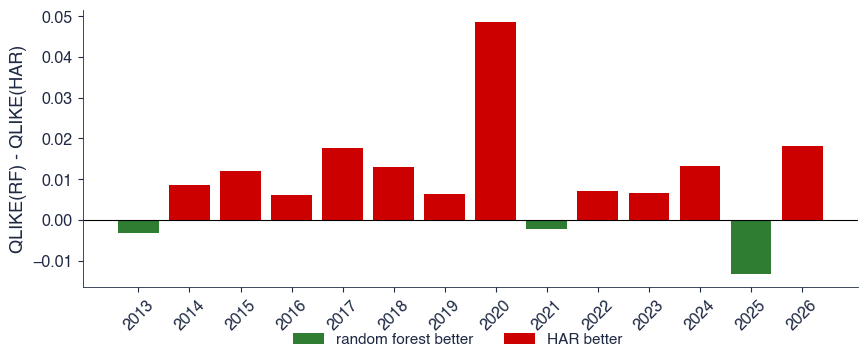

{'HAR': {'mse': 0.709137699179834,
  'r2_mean': 0.5478860430389938,
  'r2_har': 0.0,
  'qlike': 0.329258131477617,
  'dm_t': nan,
  'dm_p': nan},
 'RF': {'mse': 0.731549656226292,
  'r2_mean': 0.5335971981570571,
  'r2_har': -0.031604520634538114,
  'qlike': 0.33898145312407457,
  'dm_t': 2.650460037198567,
  'dm_p': 0.008038223613584913}}

In [16]:
# Solution
b1 = b1_daily('sp500', save=False)
{m: b1[m] for m in ('HAR', 'RF')}

**Interpretation of the result.** No: with the same three features the forest is significantly worse than the linear HAR; the relation is close to linear in logs and the forest only adds variance.

## B2 [Proposed]: weekly volatility of the DAX

**Question.** Do lasso, random forest, gradient boosting or an MLP beat HAR for next week's DAX variance? Model: B1.

1. Fit the five models walk-forward from 2012, purging the last 5 training days.
2. Compute the out-of-sample $R^2$ against HAR and the mean QLIKE of each model.
3. Run the Diebold–Mariano test of each model against HAR.
4. Interpretation: which model would you use for the DAX?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: the sign of DAX returns

**Question.** Can a logit or a random forest predict whether the DAX rises tomorrow better than "always up"?

1. Fit both classifiers walk-forward from 2008, refitting each January.
2. Compute the accuracy of each model and of the majority-class baseline.
3. Test each accuracy against the baseline with the $z$ statistic, and compute the AUC.
4. Draw the accuracy by year.
5. Interpretation: does either model have skill?

**Report:** six numbers, the chart and two sentences.

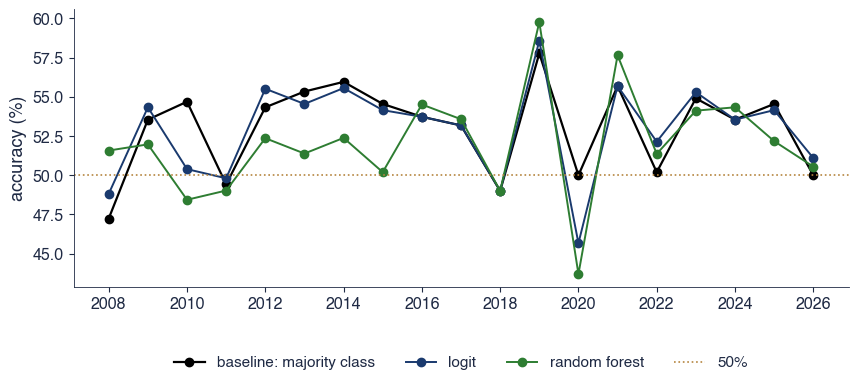

{'n': 4752,
 'up': 0.5307239057239057,
 'base_acc': 0.5307239057239057,
 'first': '2008-01-02',
 'Logit': {'acc': 0.5292508417508418,
  'diff': -0.001473063973063904,
  'z': -0.2034751059812071,
  'p': 0.8387637012355206,
  'auc': 0.5071160336127282,
  'share_up_pred': 0.9029882154882155},
 'RF': {'acc': 0.5202020202020202,
  'diff': -0.010521885521885488,
  'z': -1.453393614151543,
  'p': 0.1461144984919922,
  'auc': 0.5077669868386895,
  'share_up_pred': 0.7613636363636364},
 'years_rf_above': 8,
 'n_years': 19}

In [18]:
# Solution
b3 = b3_sign('dax', save=False)
b3

**Interpretation of the result.** No: both accuracies are at or below the baseline and the AUC is close to 0.5; daily DAX returns are close to unpredictable (Chapter 7).

## B4 [Proposed]: the sign of two BVB stocks

**Question.** Is the sign of Banca Transilvania and OMV Petrom returns easier to predict than that of the DAX? Model: B3.

1. Fit the logit, random forest and gradient boosting walk-forward from 2014.
2. Compute the accuracy, the baseline accuracy, the $z$ statistic and the AUC for each stock and model.
3. Interpretation: is there more predictability on the BVB than on the DAX?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: VaR 1% of the DAX by quantile regression

**Question.** Does a linear quantile regression on volatility features give a better VaR 1% than historical simulation?

1. Fit the 1% quantile regression walk-forward from 2012 and set VaR 1% $= -\hat q_{0.01}$.
2. Compute the historical-simulation VaR 1% on the last 500 days.
3. Count the exceptions and run the Kupiec and Christoffersen tests; compute the average quantile loss.
4. Draw both VaR forecasts in 2020–2022.
5. Interpretation: which VaR would you report to a risk committee?

**Report:** a table, the chart and two sentences.

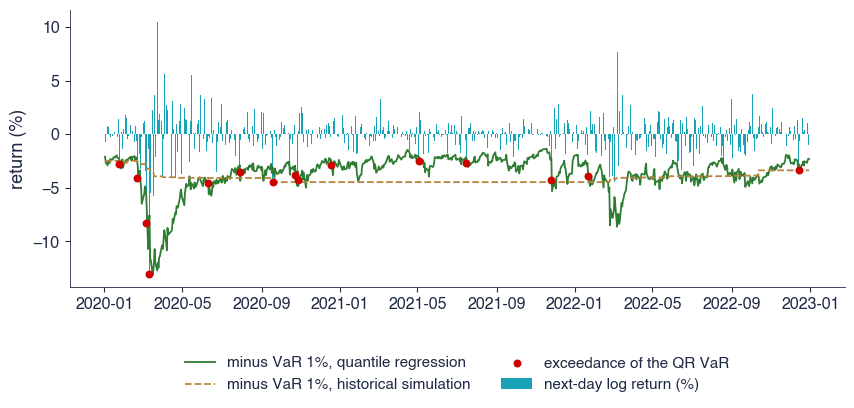

{'sd': -0.43412105655342426, 'sw': -1.8135517550229785, 'sm': -0.2210940218288013, 'r': 0.15819738761462165} -0.47240673985310544


,x,rate,lr_uc,p_uc,lr_ind,p_ind,n11,qloss,mean_var,x2020
QR,39.0,0.0105,0.0762,0.7825,0.8242,0.364,0.0,0.0380,2.9236,10.0
HS,49.0,0.0131,3.3678,0.0665,22.4581,0.000,7.0,0.0475,3.3456,13.0


In [20]:
# Solution
b5 = b5_qr('dax', save=False)
print(b5['coef'], b5['intercept'])
pd.DataFrame({m: b5[m] for m in ('QR', 'HS')}).T.round(4)

**Interpretation of the result.** The quantile regression has the right exception rate, independent exceptions and a smaller quantile loss; historical simulation is exceeded in clusters because a 500-day window reacts slowly.

## B6 [Proposed]: quantile gradient boosting for the DAX

**Question.** Does a flexible quantile model improve on the linear quantile regression of B5? Model: B5.

1. Fit the quantile boosting (300 trees of depth 2, learning rate 0.05, at least 50 days per leaf) walk-forward from 2012 and compute its VaR 1%.
2. Count the exceptions, run the Kupiec and Christoffersen tests and compute the quantile loss.
3. Interpretation: is the flexible model worth it at the 1% level?

**Report:** one table and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: does the S&P 500 help to forecast BET volatility?

**Question.** The BVB closes before New York; does yesterday's S&P 500 volatility improve a HAR forecast of next week's BET variance? Models: B1, B2.

1. Build the HAR features of the BET (squared daily returns as the proxy) and the HAR features of the S&P 500 at the previous New York close.
2. Compare HAR, HAR plus the S&P 500 features (OLS) and a random forest on all features, walk-forward from 2012.
3. Compute the out-of-sample $R^2$, QLIKE and the Diebold–Mariano tests against HAR.
4. Interpretation: is the S&P 500 information worth adding?

**Report:** a table and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant summarised machine learning for the S&P 500. It answered:

- (a) with random 5-fold cross-validation a random forest explains more than a third of the next 21-day return: the market is predictable;
- (b) the forest fits next week's log variance better than HAR, judging by the in-sample $R^2$;
- (c) a forest that predicts the sign of tomorrow's return correctly on 53% of the days beats a coin, so it has skill;
- (d) for the VaR 99% use quantile regression at $\tau = 0.99$ on the next-day return;
- (e) the lasso removes the features whose t-statistics are not significant;
- (f) QLIKE punishes an under-forecast of the variance more than an over-forecast by the same factor.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
